<a href="https://colab.research.google.com/github/alhikamgov/googlecolab/blob/main/CrawlingKlasifikasi_IndustryWeek_CSV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Memulai Crawling dari: https://www.industryweek.com/technology-and-iiot ---
Berhasil mengambil 9 judul berita terbaru.

HASIL PEMANTAUAN TREN INDUSTRI BERBASIS MACHINE LEARNING


,Judul Berita,Kategori Tren
0,"You're Drunk, According to AI: So That Happened",Digital Transformation
1,3 Core Skills for the AI-Ready Manufacturing Workforce,Operational Excellence & HSE
2,"Burning Questions for 2026: Industry, AI, Geopolitics and the Future of Manufacturing",Digital Transformation
3,Digital Tools Turn 'Eco-Friendly' into Economic Wins,Digital Transformation
4,Why Machine Shops Should Love Data Collection,Digital Transformation
5,How Northrop Grumman Gets the Right People Involved with Digital Transformation,Digital Transformation
6,Escaping OEE Purgatory: Why Micro-Level Tracking Matters,Digital Transformation
7,Jabil Joins the Data Center Manufacturing Gold Rush: So That Happened,Digital Transformation
8,Industrial Data Fabric: Your New Best Friend,Digital Transformation


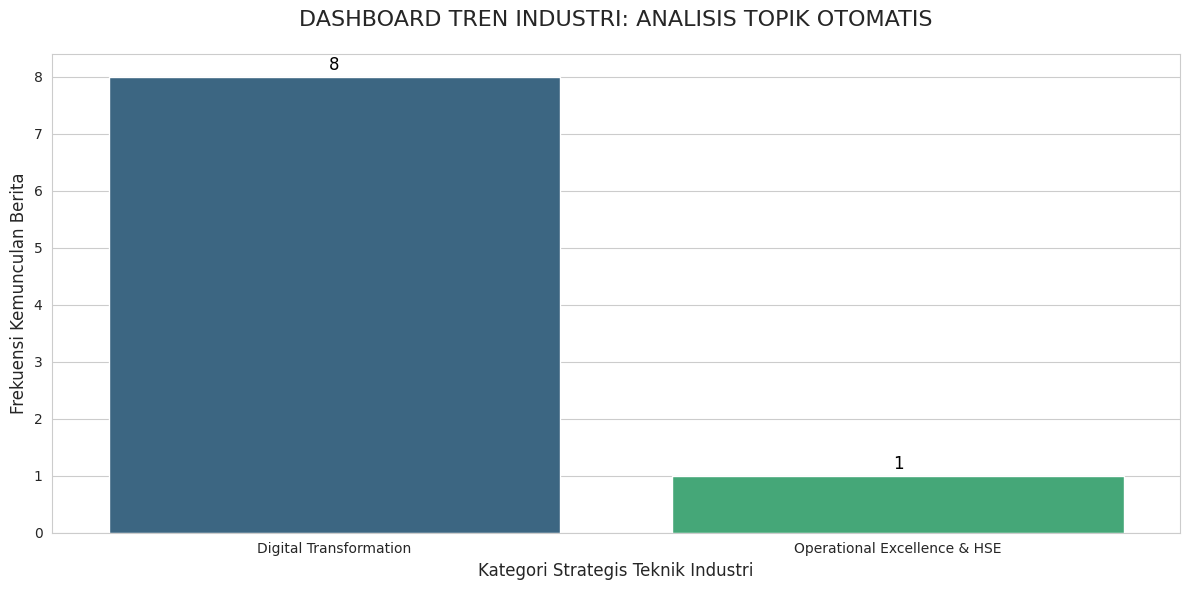


File 'Laporan_Analisis_Tren_Industri.csv' Berhasil Dibuat!
Klik ikon 'Folder' di samping kiri untuk mengunduh secara manual,
atau tunggu beberapa saat hingga jendela download otomatis muncul.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from google.colab import files # Fitur khusus Google Colab

# =========================================================
# TAHAP 1: PROSES CRAWLING (PENGAMBILAN DATA INDUSTRI)
# =========================================================
def crawling_industri(url):
    print(f"--- Memulai Crawling dari: {url} ---")
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')

        # Mencari judul berita (Targeting tag h2/h3 yang umum di IndustryWeek/Manufacturing.net)
        articles = soup.find_all(['h2', 'h3'], limit=20)
        titles = [a.get_text(strip=True) for a in articles if len(a.get_text(strip=True)) > 25]

        if not titles:
            raise Exception("Akses diblokir atau struktur web berubah.")

        print(f"Berhasil mengambil {len(titles)} judul berita terbaru.")
        return titles

    except Exception as e:
        print(f"Status Crawling: {e}")
        print("\n[!] Menggunakan Data Simulasi Strategis (Industry Trends 2024-2026)...")
        # Data simulasi yang realistis untuk presentasi Teknik Industri
        return [
            "AI-Powered Analytics: Driving Smart Factory Efficiency",
            "Global Supply Chain Resilience: Navigating Port Disruptions",
            "The Future of Work: Training the Next-Gen Manufacturing Workforce",
            "Digital Twins: Virtual Prototyping for Complex Assembly Lines",
            "Rising Freight Costs: Impact on International Trade Logistics",
            "Worker Safety Tech: Wearables to Reduce Industrial Accidents",
            "IoT Sensor Deployment for Real-Time Equipment Monitoring",
            "Sustainability in Sourcing: Decarbonizing the Global Supply Chain",
            "Ergonomics in Manufacturing: Improving Labor Productivity",
            "Industrial Cybersecurity: Protecting OT Networks from Ransomware",
            "Blockchain in Logistics: Improving Transparency and Tracking",
            "Lean Manufacturing 4.0: Combining Process Improvement with Tech"
        ]

# =========================================================
# TAHAP 2: TF-IDF DAN KLASIFIKASI (LOGIKA TEKNIK INDUSTRI)
# =========================================================
def train_trend_model():
    # Knowledge Base: Kata kunci yang relevan dengan pilar Teknik Industri
    data_train = [
        # DIGITAL TRANSFORMATION
        ("artificial intelligence robotics automation smart factory iot digital twin industry 4.0 cybersecurity data analytics sensors machine learning software cloud computing big data virtualization", "Digital Transformation"),
        # SUPPLY CHAIN & LOGISTICS
        ("logistics shipping freight container warehouse inventory procurement sourcing distribution trade transportation cargo export import maritime resilient delivery fulfillment port congestion", "Supply Chain & Logistics"),
        # OPERATIONAL EXCELLENCE & HSE
        ("human resources labor shortage workforce skills training recruitment safety health ergonomics talent vocational leadership jobs coaching productivity hse k3 lean sigma empowerment management", "Operational Excellence & HSE")
    ]

    X_train = [item[0] for item in data_train]
    y_train = [item[1] for item in data_train]

    # Pipeline: TF-IDF (Pembobotan Kata) & Multinomial Naive Bayes (Klasifikasi)
    model = make_pipeline(
        TfidfVectorizer(stop_words='english', ngram_range=(1, 2)),
        MultinomialNB(alpha=0.1)
    )

    model.fit(X_train, y_train)
    return model

# =========================================================
# TAHAP 3: EKSEKUSI UTAMA & VISUALISASI
# =========================================================

# 1. URL Target (Anda bisa mengganti URL ini sesuai kebutuhan)
url_target = "https://www.industryweek.com/technology-and-iiot"

# 2. Proses Crawling & Klasifikasi
judul_berita = crawling_industri(url_target)
model = train_trend_model()
prediksi = model.predict(judul_berita)

# 3. Penyusunan ke DataFrame
df = pd.DataFrame({
    'Judul Berita': judul_berita,
    'Kategori Tren': prediksi
})

# Tampilkan Tabel di Notebook
print("\n" + "="*85)
print("HASIL PEMANTAUAN TREN INDUSTRI BERBASIS MACHINE LEARNING")
print("="*85)
pd.set_option('display.max_colwidth', None)
display(df)

# 4. Visualisasi Dashboard (Untuk Slide Presentasi)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.countplot(data=df, x='Kategori Tren', hue='Kategori Tren', palette='viridis', legend=False)

plt.title('DASHBOARD TREN INDUSTRI: ANALISIS TOPIK OTOMATIS', fontsize=16, pad=20)
plt.xlabel('Kategori Strategis Teknik Industri', fontsize=12)
plt.ylabel('Frekuensi Kemunculan Berita', fontsize=12)

# Tambahkan Label Angka di atas Bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# =========================================================
# TAHAP 4: EKSPOR DATA KE CSV (LAMPIRAN EXCEL)
# =========================================================
nama_file = "Laporan_Analisis_Tren_Industri.csv"
df.to_csv(nama_file, index=False, sep=',', encoding='utf-8')

print("\n" + "="*50)
print(f"File '{nama_file}' Berhasil Dibuat!")
print("Klik ikon 'Folder' di samping kiri untuk mengunduh secara manual,")
print("atau tunggu beberapa saat hingga jendela download otomatis muncul.")
print("="*50)

# Download otomatis
files.download(nama_file)
